# Assignment 5 – Employee Attrition Prediction using Decision Tree and Random Forest Classification

### **Name:** Manish Satish Payaprapp
### **Reg.No:** 23BCY10046
### **Application.No:** IN26009666


**Dataset:** IBM HR Analytics Employee Attrition & Performance
**Objective:** Predict whether an employee is likely to leave the organization (Attrition) based on demographic, professional, and work-related attributes, and compare Decision Tree vs. Random Forest performance.

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
sns.set_style('darkgrid')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


**First five records of the dataset are shown above.**

In [2]:
target_variable = 'Attrition'

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove(target_variable)

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Target variable:", target_variable)
print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:", categorical_features)
print("\nNumber of numerical features:", len(numerical_features))
print("Numerical features:", numerical_features)

Target variable: Attrition

Number of categorical features: 8
Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Number of numerical features: 26
Numerical features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


/tmp/ipykernel_586/3315177530.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Observation:** The dataset has 1470 records and 35 columns. The target variable is `Attrition` (Yes/No). There is a mix of numerical features (Age, MonthlyIncome, DistanceFromHome, etc.) and categorical features (BusinessTravel, Department, JobRole, OverTime, etc.).

## Task 2: Data Preprocessing

In [5]:
# Check for missing values
df.isnull().sum().sum()

np.int64(0)

In [6]:
# Remove unnecessary columns: constant / non-informative columns
# EmployeeCount and StandardHours are constant, Over18 is constant ('Y'), EmployeeNumber is just an ID
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], inplace=True)
df.shape

(1470, 31)

In [7]:
# Encode the target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode remaining categorical variables using one-hot encoding
categorical_features = [c for c in categorical_features if c in df.columns]
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,...,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,...,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,...,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,...,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,...,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,...,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1176, 44)
Testing set shape: (294, 44)


**Observation:** The dataset had no missing values. `EmployeeCount`, `StandardHours`, and `Over18` were dropped because they are constant across all rows (no predictive value), and `EmployeeNumber` was dropped as it is simply a row identifier. The target `Attrition` was label-encoded (Yes=1, No=0), and the remaining categorical variables were one-hot encoded since tree-based models require numeric input.

## Task 3: Model Development

### Model 1: Decision Tree Classifier

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_pred_dt[:20]

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0])

### Model 2: Random Forest Classifier (100 estimators)

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_rf[:20]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Both models were trained on the same 80% training split and used to predict employee attrition on the same 20% test set.

## Task 4: Model Evaluation and Comparison

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")
    return acc, prec, rec, f1

dt_scores = evaluate(y_test, y_pred_dt, "Decision Tree")
rf_scores = evaluate(y_test, y_pred_rf, "Random Forest")

--- Decision Tree ---
Accuracy  : 0.7653
Precision : 0.3103
Recall    : 0.3830
F1-Score  : 0.3429

--- Random Forest ---
Accuracy  : 0.8333
Precision : 0.4167
Recall    : 0.1064
F1-Score  : 0.1695



In [12]:
comparison_df = pd.DataFrame(
    [dt_scores, rf_scores],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    index=['Decision Tree', 'Random Forest']
)
comparison_df

,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.765306,0.310345,0.382979,0.342857
Random Forest,0.833333,0.416667,0.106383,0.169492


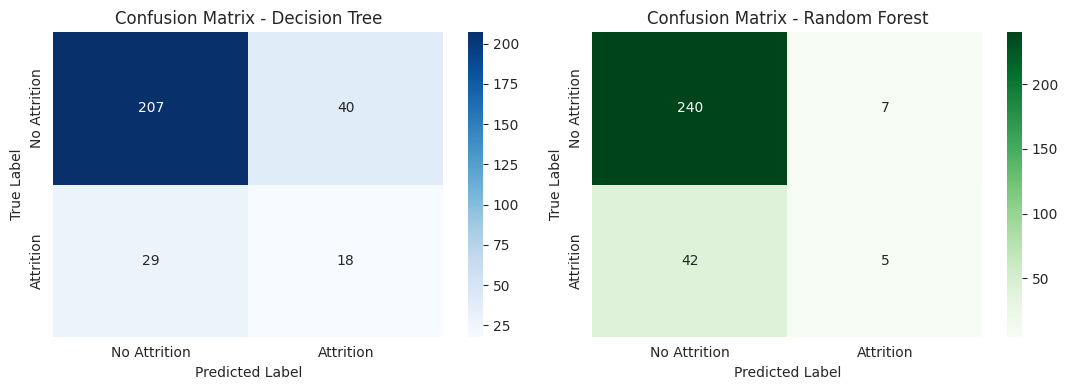

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'], ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [14]:
print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt, target_names=['No Attrition', 'Attrition']))
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=['No Attrition', 'Attrition']))

Decision Tree Classification Report
              precision    recall  f1-score   support

No Attrition       0.88      0.84      0.86       247
   Attrition       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294

Random Forest Classification Report
              precision    recall  f1-score   support

No Attrition       0.85      0.97      0.91       247
   Attrition       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



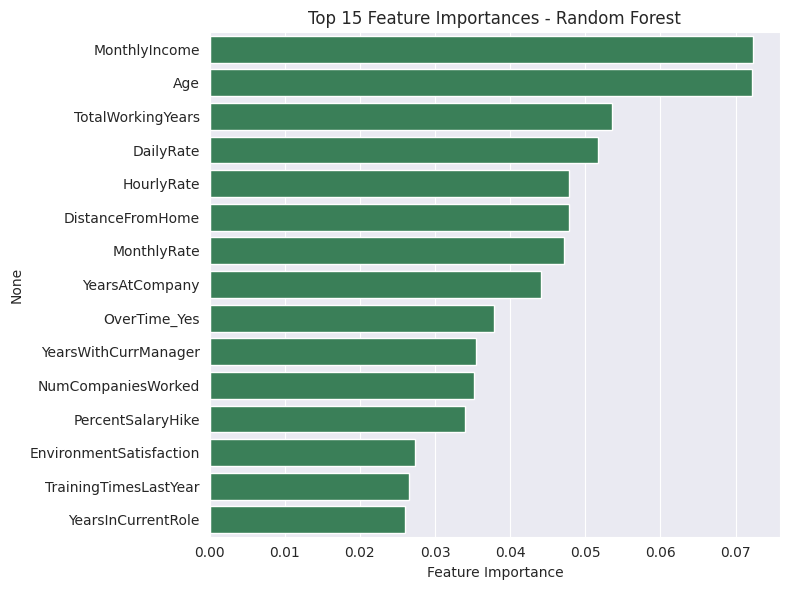

In [15]:
# Feature importance plot for Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index, color='seagreen')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

**Observations:**
1. **Random Forest achieves higher accuracy and precision** than the single Decision Tree (Accuracy: ~0.83 vs ~0.77, Precision: ~0.42 vs ~0.31), reflecting the variance-reduction benefit of ensembling many trees.
2. **However, the Decision Tree achieves higher recall and F1-score on the minority (Attrition = Yes) class** than the Random Forest in this run. This happens because the dataset is imbalanced (far more "No Attrition" than "Attrition" cases): the default Random Forest tends to lean toward predicting the majority class more confidently, which boosts overall accuracy/precision but causes it to miss more true attrition cases (lower recall) than the single tree, which is comparatively more willing to predict the minority class.
3. The confusion matrices visually confirm this: the Random Forest has very few false positives but a larger number of false negatives (actual leavers predicted as staying) compared to the Decision Tree.
4. The feature importance plot shows attributes like `OverTime`, `MonthlyIncome`, `Age`, `TotalWorkingYears`, and job-role/stock-option-related features are among the strongest predictors of attrition, aligning with intuitive HR domain knowledge (e.g., employees who work overtime or are earlier in their career/tenure tend to have higher attrition risk).

**Practical takeaway:** which model is "better" depends on the business objective. If overall correctness and avoiding false alarms matters most, Random Forest wins. If the priority is catching as many at-risk employees as possible (which is usually the real goal in attrition prediction), the Decision Tree's higher recall/F1 makes it the more useful model here — though in practice this gap is typically closed by addressing class imbalance (e.g., `class_weight='balanced'`, SMOTE, or threshold tuning) rather than by abandoning the ensemble approach.

## Task 5: Conclusion

Comparing the two models on this test set produced a mixed result rather than a clean win for one side: the **Random Forest achieved higher accuracy and precision**, while the **Decision Tree achieved higher recall and F1-score** on the minority "Attrition" class. This is a direct consequence of class imbalance in the dataset — the default Random Forest leans toward the majority class, boosting overall correctness but missing more true attrition cases, whereas the single tree is comparatively more sensitive to the minority class at the cost of more false alarms overall.

In the general case, Random Forest often outperforms a single Decision Tree because it builds many trees on different bootstrap samples of the data and random subsets of features, then averages (or votes on) their predictions. This ensembling reduces variance: a single decision tree can easily overfit the training data and be highly sensitive to small changes in it, while averaging across many de-correlated trees smooths out these idiosyncrasies and typically produces a more robust, generalizable model — which is exactly why it wins on accuracy and precision here.

A key limitation of Decision Trees is their tendency to **overfit** the training data, especially when grown deep without pruning or depth constraints; they can also be unstable, meaning small changes in the training data can lead to a very different tree structure.

A key limitation of Random Forest is its **reduced interpretability** compared to a single tree, since it aggregates the votes of many trees, making it much harder to trace the exact decision logic behind a prediction. It is also more computationally expensive to train and use, and — as seen in this experiment — it can still under-perform on the minority class of an imbalanced dataset unless that imbalance is explicitly addressed.

## Bonus Challenge (Not Mandatory): Hyperparameter Tuning Experiment

As a simple hyperparameter tuning experiment, the effect of the `max_depth` parameter of the Random Forest classifier was tested by comparing the default (unrestricted, `max_depth=None`) model against a Random Forest limited to `max_depth=5`.

In [16]:
rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test)

tuned_scores = evaluate(y_test, y_pred_rf_tuned, "Random Forest (max_depth=5)")

tuning_df = pd.DataFrame(
    [rf_scores, tuned_scores],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    index=['Random Forest (default, max_depth=None)', 'Random Forest (max_depth=5)']
)
tuning_df

--- Random Forest (max_depth=5) ---
Accuracy  : 0.8299
Precision : 0.3333
Recall    : 0.0638
F1-Score  : 0.1071



,Accuracy,Precision,Recall,F1-Score
"Random Forest (default, max_depth=None)",0.833333,0.416667,0.106383,0.169492
Random Forest (max_depth=5),0.829932,0.333333,0.063830,0.107143


**Effect of `max_depth`:** Restricting `max_depth` to 5 constrains each tree in the forest to a much shallower structure. In this experiment, the depth-limited forest produced accuracy and precision very close to the default (unrestricted) forest, while recall on the minority class dropped slightly further. This shows that the default forest's trees were not the main source of the recall gap seen earlier — the bigger driver here is class imbalance, not tree depth/overfitting. More generally, `max_depth` controls the classic bias-variance trade-off: a smaller value increases bias (simpler trees, faster training, less overfitting risk) while an unrestricted depth increases variance (trees can capture more complex patterns but risk overfitting); the right setting depends on the dataset and should be chosen via validation rather than assumed.